# Experiment V1: Faster R-CNN Baseline for Object Detection

**Student ID:** 25509225  
**Experiment:** V1 - Faster R-CNN Baseline (Standard Model)  
**Model:** Faster R-CNN with ResNet50+FPN (no customization)

---

## Overview

This experiment trains a standard Faster R-CNN model on the solar panel damage detection dataset without any architectural modifications. This serves as the baseline for comparison with customized models (V2: Deeper Backbone, V3: Shallower Backbone).

## Cell 1: Load Modules

In [2]:
# Load shared modules from FasterRCNN_modules.ipynb
%run ./FasterRCNN_modules.ipynb

# Load data loading utilities
%run ./FasterRCNN_DataLoader.ipynb

print("✓ All modules loaded successfully")

✓ All required dependencies already installed

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB

Package Versions:
  PyTorch: 2.8.0
  Torchvision: 0.24.0
  OpenCV: 4.13.0
  NumPy: 1.26.4
✓ FasterRCNNDetector class defined successfully
✓ FasterRCNNTrainer class defined successfully
✓ DetectionEvaluator class defined successfully
✓ torchvision already installed
✓ All imports successful
✓ FasterRCNNDataset class defined successfully
✓ create_faster_rcnn_dataloaders function defined successfully
✓ All modules loaded successfully


## Cell 2: Configuration

In [3]:
# ============================================================================
# Experiment V1: Faster R-CNN Baseline Configuration
# ============================================================================

# === Dataset Configuration ===
STUDENT_ID = "25509225"
# Use absolute path for SageMaker environment
DATA_ROOT = f"/home/sagemaker-user/CNN_A2/data/{STUDENT_ID}/Object_Detection/coco"
ANNOTATION_FORMAT = 'coco'
CLASS_NAMES = ['Cell', 'Cell-Multi', 'No-Anomaly', 'Shadowing', 'Unclassified']
# =========================================================
# Version 3 — Large Proposal Capacity
# Goal:
# Keep more candidate boxes for crowded scenes
# =========================================================

MODEL_CONFIG_V1 = {
    'num_classes': len(CLASS_NAMES) + 1,
    'pretrained': True,
    'min_size': 640,
    'max_size': 640,
    'customize_type': None,

    'anchor_sizes': ((32,), (64,), (128,), (256,), (512,)),
    'anchor_aspect_ratios': ((0.5, 1.0, 2.0),) * 5,

    # Modified: larger proposal capacity
    'rpn_pre_nms_top_n_train': 4000,
    'rpn_post_nms_top_n_train': 2000,
    'rpn_pre_nms_top_n_test': 2000,
    'rpn_post_nms_top_n_test': 1000,

    'rpn_nms_thresh': 0.7,
    'box_nms_thresh': 0.5,

    'rpn_fg_iou_thresh': 0.7,
    'rpn_bg_iou_thresh': 0.3
}

TRAINING_CONFIG_V1 = {
    'learning_rate': 0.005,
    'batch_size': 4,
    'epochs': 300,
    'optimizer': 'sgd',
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'patience': 30,
}

# === Output Directory ===
output_dir = Path('/home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1')
output_dir.mkdir(parents=True, exist_ok=True)

# Print experiment info
print("=" * 80)
print("EXPERIMENT V1: Faster R-CNN Baseline")
print("=" * 80)
print(f"\nDataset Configuration:")
print(f"  Student ID: {STUDENT_ID}")
print(f"  Data Root: {DATA_ROOT}")
print(f"  Annotation Format: {ANNOTATION_FORMAT}")
print(f"  Classes: {CLASS_NAMES}")
print(f"  Number of Classes: {len(CLASS_NAMES)} (+ background)")

print("\nModel Configuration:")
for key, value in MODEL_CONFIG_V1.items():
    print(f"  {key}: {value}")

print("\nTraining Configuration:")
for key, value in TRAINING_CONFIG_V1.items():
    print(f"  {key}: {value}")

print(f"\nOutput Directory: {output_dir}")

EXPERIMENT V1: Faster R-CNN Baseline

Dataset Configuration:
  Student ID: 25509225
  Data Root: /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/coco
  Annotation Format: coco
  Classes: ['Cell', 'Cell-Multi', 'No-Anomaly', 'Shadowing', 'Unclassified']
  Number of Classes: 5 (+ background)

Model Configuration:
  num_classes: 6
  pretrained: True
  min_size: 640
  max_size: 640
  customize_type: None
  anchor_sizes: ((32,), (64,), (128,), (256,), (512,))
  anchor_aspect_ratios: ((0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0))
  rpn_pre_nms_top_n_train: 4000
  rpn_post_nms_top_n_train: 2000
  rpn_pre_nms_top_n_test: 2000
  rpn_post_nms_top_n_test: 1000
  rpn_nms_thresh: 0.7
  box_nms_thresh: 0.5
  rpn_fg_iou_thresh: 0.7
  rpn_bg_iou_thresh: 0.3

Training Configuration:
  learning_rate: 0.005
  batch_size: 4
  epochs: 300
  optimizer: sgd
  momentum: 0.9
  weight_decay: 0.0005
  patience: 30

Output Directory: /home/sagemaker-user/CNN_A2/no

## Cell 3: Step 1 - Create DataLoaders

In [4]:
# ============================================================================
# Step 1: Create DataLoaders
# ============================================================================

print("\n[1/5] Creating dataloaders...")
print("=" * 80)

# create_faster_rcnn_dataloaders is already imported from FasterRCNN_DataLoader.ipynb

train_loader, val_loader, test_loader = create_faster_rcnn_dataloaders(
    data_root=DATA_ROOT,
    batch_size=TRAINING_CONFIG_V1['batch_size'],
    num_workers=4,
    annotation_format=ANNOTATION_FORMAT,
    class_names=CLASS_NAMES
)

print(f'\nDataset loaded successfully:')
print(f'  Train samples: {len(train_loader.dataset)}')
print(f'  Val samples: {len(val_loader.dataset)}')
print(f'  Test samples: {len(test_loader.dataset)}')
print(f'  Invalid bboxes filtered:')
print(f'    Train: {train_loader.dataset.skipped_annotations}')
print(f'    Val: {val_loader.dataset.skipped_annotations}')
print(f'    Test: {test_loader.dataset.skipped_annotations}')
print("\n✓ Dataloaders created successfully")


[1/5] Creating dataloaders...
  ℹ️  445 images without annotations (background images)
Loaded 1167 samples from /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/coco/train
Classes: ['Cell', 'Cell-Multi', 'No-Anomaly', 'Shadowing', 'Unclassified']
  ℹ️  102 images without annotations (background images)
Loaded 250 samples from /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/coco/valid
Classes: ['Cell', 'Cell-Multi', 'No-Anomaly', 'Shadowing', 'Unclassified']
  ℹ️  95 images without annotations (background images)
Loaded 250 samples from /home/sagemaker-user/CNN_A2/data/25509225/Object_Detection/coco/test
Classes: ['Cell', 'Cell-Multi', 'No-Anomaly', 'Shadowing', 'Unclassified']

BOUNDING BOX VALIDATION REPORT
Train dataset: 0 invalid bboxes skipped during loading
Valid dataset: 0 invalid bboxes skipped during loading
Test dataset: 0 invalid bboxes skipped during loading

💡 NOTE: Invalid bboxes (width ≤ 0 or height ≤ 0) are automatically filtered
   This prevents Fa

## Cell 4: Step 2 - Initialize Model

In [5]:
# ============================================================================
# Step 2: Initialize Faster R-CNN Model
# ============================================================================

print("\n[2/5] Initializing Faster R-CNN model...")
print("=" * 80)

# Create model
model = FasterRCNNDetector(**MODEL_CONFIG_V1)

print(f'Number of classes: {MODEL_CONFIG_V1["num_classes"]} ({len(CLASS_NAMES)} + background)')
print(f'Image size: {MODEL_CONFIG_V1["min_size"]}x{MODEL_CONFIG_V1["max_size"]}')
print(f'Pretrained backbone: {MODEL_CONFIG_V1["pretrained"]}')
print(f'Customization: None (Baseline)')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}, Trainable: {trainable_params:,}')
print(f'Approximate: ~{total_params/1e6:.1f}M parameters')
print("\n✓ Model initialized successfully")


[2/5] Initializing Faster R-CNN model...
Number of classes: 6 (5 + background)
Image size: 640x640
Pretrained backbone: True
Customization: None (Baseline)
Total params: 41,319,661, Trainable: 41,097,261
Approximate: ~41.3M parameters

✓ Model initialized successfully


## Cell 5: Step 3 - Train Model

In [6]:
# ============================================================================
# Step 3: Train Model
# ============================================================================

print("\n[3/5] Training model...")
print("=" * 80)

# Initialize trainer
trainer = FasterRCNNTrainer(TRAINING_CONFIG_V1)

# Train model
history = trainer.train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=str(output_dir / 'training')
)

print(f'\nTraining completed!')
print(f'Best training loss: {history["best_loss"]:.4f}')
print(f'Total epochs: {history["total_epochs"]}')
print(f'Early stopped: {history["early_stopped"]}')
print("\n✓ Model training completed successfully")


[3/5] Training model...
FASTER R-CNN TRAINING
Found existing checkpoint: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/training/checkpoints/latest_checkpoint.pth
Resumed from epoch 73, best mAP@0.5: 0.7005
Early stop counter: 30/30
Best training loss: 0.0819
Appending to existing CSV: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/training/training_history.csv

Model Architecture:
  Total trainable parameters: 41,097,261
Training configuration:
  Epochs: 300 (starting from 73)
  Learning rate: 0.005
  Weight decay: 0.0005
  Device: cuda
  Early stopping patience: 30
  Mixed precision (AMP): True
  CSV logging: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/training/training_history.csv
  Checkpoint saving: Every epoch


Epoch 74/300 [Eval]: 100%|██████████| 63/63 [00:11<00:00,  5.32it/s, batch=4]


Epoch 74/300 [Eval] completed: P=0.976, R=0.715, mAP@0.5=0.698, mAP@0.5:0.95=0.674

Early stopping triggered at epoch 74
✓ Loss curve saved to: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/training/loss_curve.png
✓ mAP curve saved to: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/training/map_curve.png

Training completed!
  Best training loss: 0.0800
  Total epochs: 74
  Early stopped: True

Training completed!
Best training loss: 0.0800
Total epochs: 74
Early stopped: True

✓ Model training completed successfully


## Cell 6: Step 4 - Evaluate on Test Set

In [8]:
# ============================================================================
# Step 4: Evaluate on Test Set
# ============================================================================

print("\n[4/5] Evaluating model on test set...")
print("=" * 80)

# Initialize evaluator
evaluator = DetectionEvaluator()

# Evaluate model
metrics = evaluator.evaluate_fasterrcnn(
    model=model,
    test_loader=test_loader,
    output_dir=str(output_dir / 'evaluation'),
    class_names=CLASS_NAMES
)

print(f'\nTest Set Metrics:')
print(f'  mAP@0.5: {metrics["mAP50"]:.4f}')
print(f'  mAP@0.5:0.95: {metrics["mAP50_95"]:.4f}')
print(f'  Precision: {metrics["precision"]:.4f}')
print(f'  Recall: {metrics["recall"]:.4f}')
print("\n✓ Model evaluation completed successfully")


[4/5] Evaluating model on test set...
Running evaluation on test set...


Evaluating: 100%|██████████| 63/63 [00:12<00:00,  4.96it/s]



Generating confusion matrix...
✓ Confusion matrix saved to: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/evaluation/confusion_matrix.png
✓ Normalized confusion matrix saved to: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/evaluation/confusion_matrix_normalized.png

Generating PR curves data (per-class)...
✓ PR curves data saved to: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/evaluation/pr_curves_data.json

Evaluation completed:
  mAP@0.5: 0.6685
  mAP@0.5:0.95: 0.6358
  Precision: 0.9839
  Recall: 0.6795
  F1-Score: 0.8038
  Saved to: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1/evaluation/evaluation_metrics.json

Test Set Metrics:
  mAP@0.5: 0.6685
  mAP@0.5:0.95: 0.6358
  Precision: 0.9839
  Recall: 0.6795

✓ Model evaluation completed successfully


## Cell 7: Visualization


=== Detection Results Visualization ===


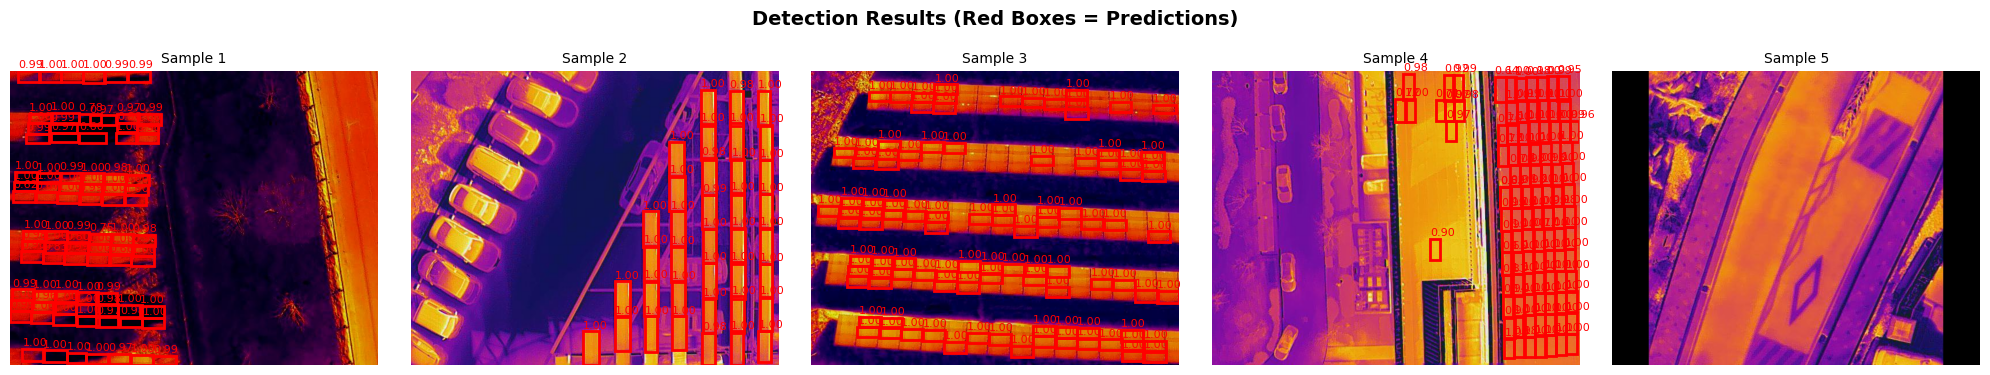


✓ Detection results displayed


In [9]:
# ============================================================================
# Visualization 1: Detection Results (Bounding Boxes)
# ============================================================================

print("\n=== Detection Results Visualization ===")
print("=" * 80)

# Display detection results inline
fig = evaluator.plot_detection_results(model, test_loader, num_samples=5)
if fig is not None:
    plt.show()
    print("\n✓ Detection results displayed")
else:
    print("Warning: Could not generate detection visualization")


=== Training Loss Curves ===


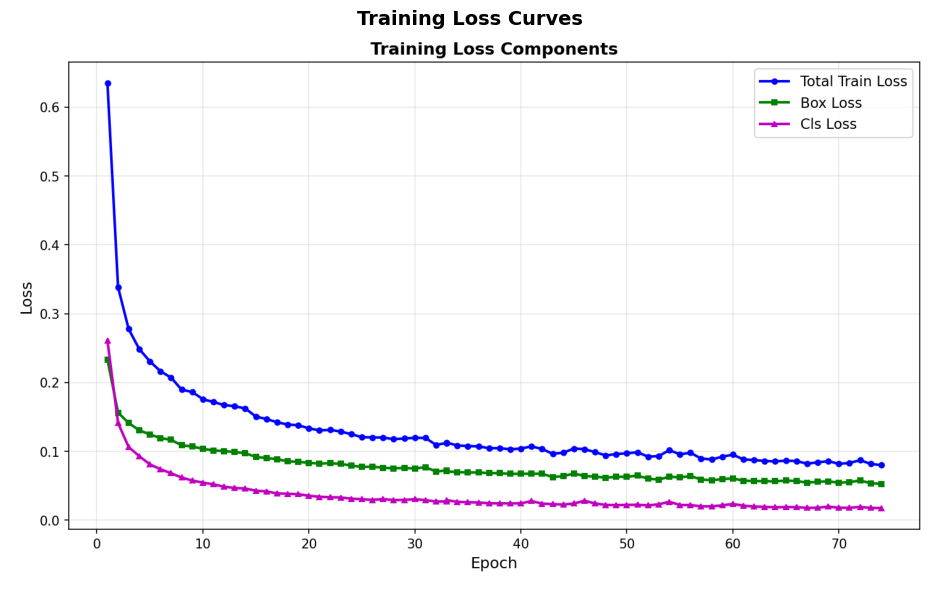


✓ Training loss curves displayed


In [10]:
# ============================================================================
# Visualization 2: Training Loss Curves
# ============================================================================

print("\n=== Training Loss Curves ===")
print("=" * 80)

# Display saved loss curve image
fig = evaluator.plot_training_losses(str(output_dir))
if fig is not None:
    plt.show()
    print("\n✓ Training loss curves displayed")
else:
    print("Warning: Could not display training loss curves")
    print("This may be because loss_curve.png was not generated.")


=== Validation mAP Curves ===


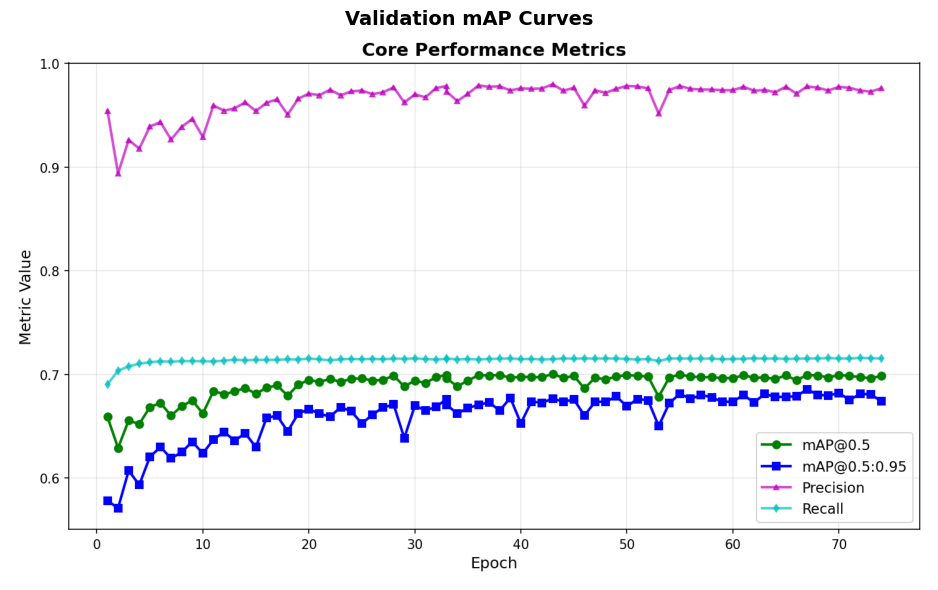


✓ Validation mAP curves displayed


In [11]:
# ============================================================================
# Visualization 3: Validation mAP Curves
# ============================================================================

print("\n=== Validation mAP Curves ===")
print("=" * 80)

# Display saved mAP curve image
fig = evaluator.plot_validation_mAP(str(output_dir))
if fig is not None:
    plt.show()
    print("\n✓ Validation mAP curves displayed")
else:
    print("Warning: Could not display validation mAP curves")
    print("This may be because map_curve.png was not generated.")


=== F1-Score Curve ===


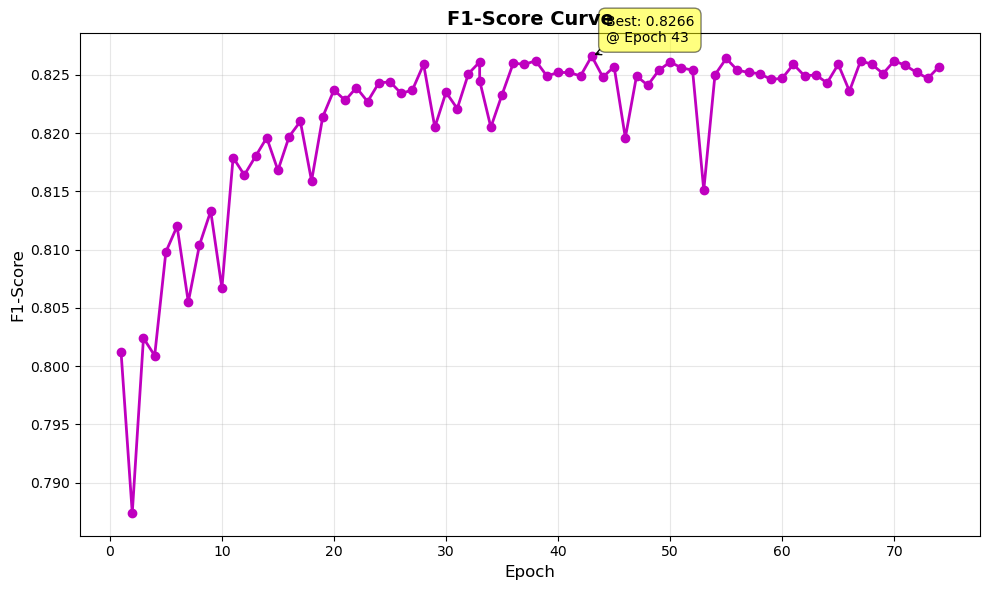


✓ F1-Score curve displayed


In [12]:
# ============================================================================
# Visualization 4: F1-Score Curve
# ============================================================================

print("\n=== F1-Score Curve ===")
print("=" * 80)

fig = evaluator.plot_f1_curve(str(output_dir))
if fig is not None:
    plt.show()
    print("\n✓ F1-Score curve displayed")
else:
    print("Warning: Could not generate F1-Score curve")


=== Confusion Matrix ===


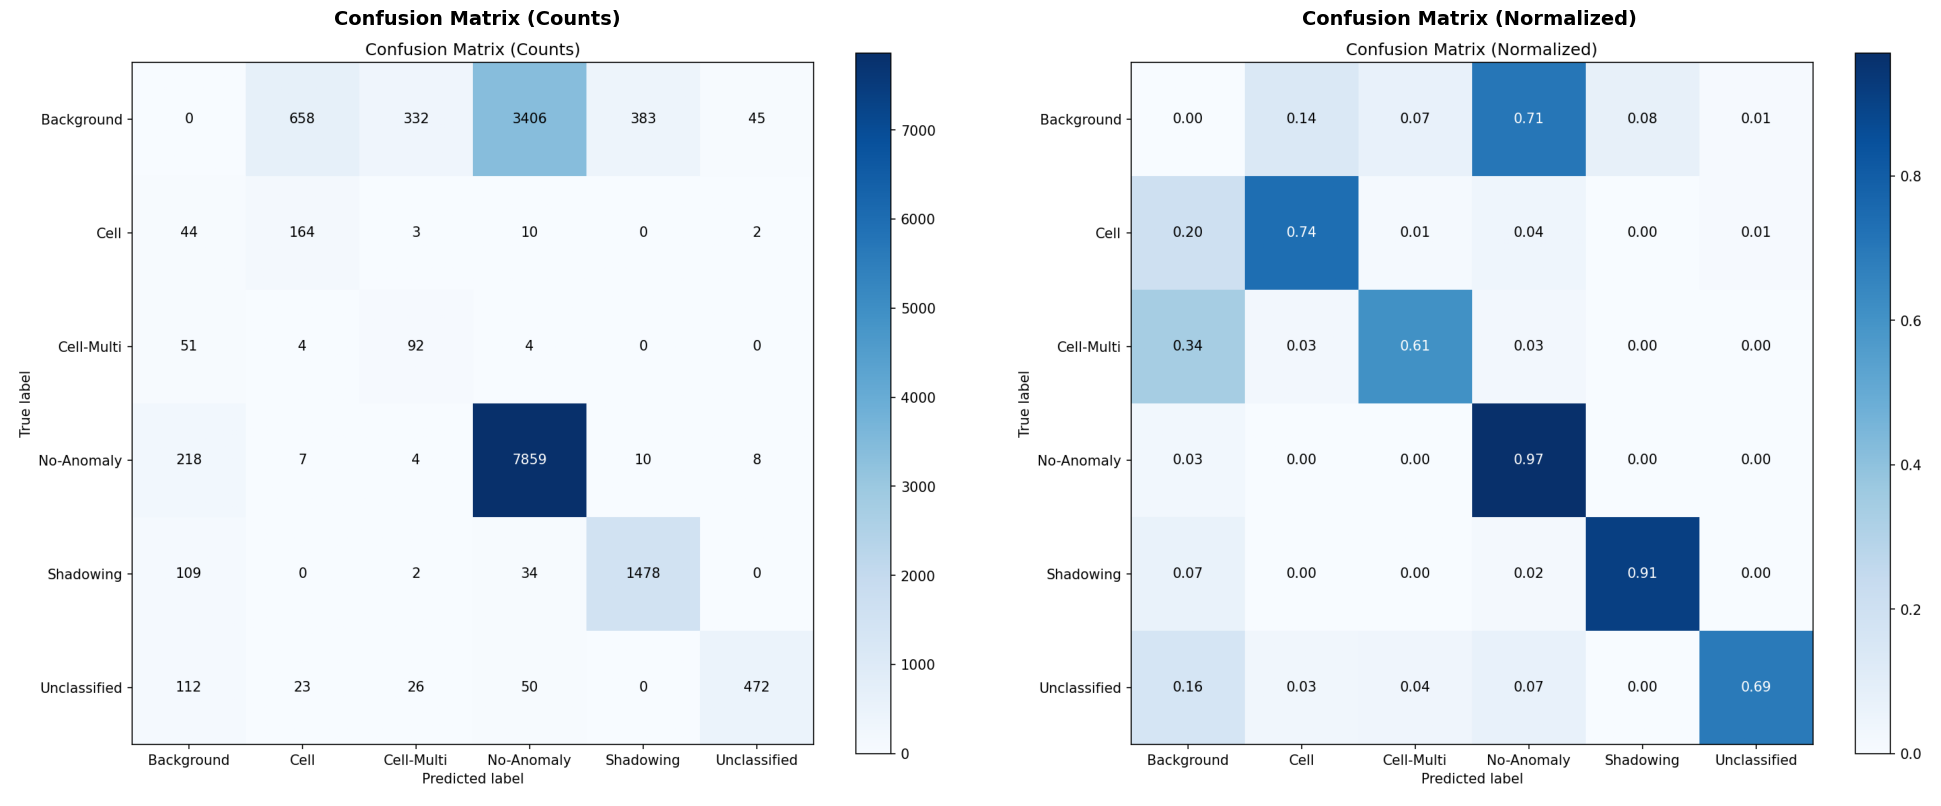


✓ Confusion matrix displayed


In [13]:
# ============================================================================
# Visualization 5: Confusion Matrix
# ============================================================================

print("\n=== Confusion Matrix ===")
print("=" * 80)

fig = evaluator.plot_confusion_matrix(str(output_dir / 'evaluation'))
if fig is not None:
    plt.show()
    print("\n✓ Confusion matrix displayed")
else:
    print("Warning: Could not generate confusion matrix")

In [14]:
# ============================================================================
# Analysis: Model Characteristics and Performance
# ============================================================================

print("\n" + "=" * 80)
print("MODEL ANALYSIS")
print("=" * 80)

# Model characteristics
total_params = sum(p.numel() for p in model.parameters())

print(f"\nModel Characteristics:")
print(f"  Backbone: ResNet50+FPN (Standard)")
print(f"  Input Size: {MODEL_CONFIG_V1['min_size']}x{MODEL_CONFIG_V1['max_size']}")
print(f"  Total Parameters: ~{total_params/1e6:.1f}M")
print(f"  Customization: None (Baseline)")
print(f"  Pretrained Weights: {MODEL_CONFIG_V1['pretrained']}")

print(f"\nPerformance Summary:")
print(f"  Best Training Loss: {history['best_loss']:.4f}")
print(f"  Total Epochs: {history['total_epochs']}")
print(f"  Test mAP@0.5: {metrics['mAP50']:.4f}")
print(f"  Test mAP@0.5:0.95: {metrics['mAP50_95']:.4f}")
print(f"  Test Precision: {metrics['precision']:.4f}")
print(f"  Test Recall: {metrics['recall']:.4f}")
f1 = 2 * metrics['precision'] * metrics['recall'] / (metrics['precision'] + metrics['recall'] + 1e-6)
print(f"  Test F1-Score: {f1:.4f}")


MODEL ANALYSIS

Model Characteristics:
  Backbone: ResNet50+FPN (Standard)
  Input Size: 640x640
  Total Parameters: ~41.3M
  Customization: None (Baseline)
  Pretrained Weights: True

Performance Summary:
  Best Training Loss: 0.0800
  Total Epochs: 74
  Test mAP@0.5: 0.6685
  Test mAP@0.5:0.95: 0.6358
  Test Precision: 0.9839
  Test Recall: 0.6795
  Test F1-Score: 0.8038


In [15]:
# ============================================================================
# Final Summary
# ============================================================================

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED")
print("=" * 80)

print(f"\nExperiment: V1 - Faster R-CNN Baseline")
print(f"Model: Standard Faster R-CNN with ResNet50+FPN")
print(f"Pretrained: {MODEL_CONFIG_V1['pretrained']}")
print(f"Customization: None (Baseline)")

print(f"\n" + "-" * 80)
print(f"Training Performance:")
print(f"  Best Training Loss: {history['best_loss']:.4f}")
print(f"  Total Epochs: {history['total_epochs']}")

print(f"\n" + "-" * 80)
print(f"Test Set Performance:")
print(f"  mAP@0.5: {metrics['mAP50']:.4f}")
print(f"  mAP@0.5:0.95: {metrics['mAP50_95']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall: {metrics['recall']:.4f}")
f1_final = 2 * metrics['precision'] * metrics['recall'] / (metrics['precision'] + metrics['recall'] + 1e-6)
print(f"  F1-Score: {f1_final:.4f}")

print(f"\n" + "-" * 80)
print(f"Output Directory: {output_dir}")
print("\n" + "=" * 80)
print("✓ All experiments completed successfully")
print("=" * 80)


EXPERIMENT COMPLETED

Experiment: V1 - Faster R-CNN Baseline
Model: Standard Faster R-CNN with ResNet50+FPN
Pretrained: True
Customization: None (Baseline)

--------------------------------------------------------------------------------
Training Performance:
  Best Training Loss: 0.0800
  Total Epochs: 74

--------------------------------------------------------------------------------
Test Set Performance:
  mAP@0.5: 0.6685
  mAP@0.5:0.95: 0.6358
  Precision: 0.9839
  Recall: 0.6795
  F1-Score: 0.8038

--------------------------------------------------------------------------------
Output Directory: /home/sagemaker-user/CNN_A2/notebooks/detection_FasterRCNN/outputs/detection_fasterrcnn_baseline_v1

✓ All experiments completed successfully
